# TikTok Viral Growth Model
### Mathematical Simulation of Video View Dynamics

**Model:**

$$\frac{dV}{dt} = \alpha_0 \cdot w^s \cdot V(t) \cdot \left(1 - \frac{V(t)}{K}\right) \cdot \sigma(V(t) - V_{th}) + \beta \cdot r \cdot V(t)$$

where the sigmoid gate is:

$$\sigma(V - V_{th}) = \frac{1}{1 + e^{-k(V - V_{th})}}$$

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print('Libraries loaded!')

Libraries loaded!


---
## 1. Define the Model Functions

In [ ]:
def sigmoid(V, V_th, k=0.001):
    """
    Sigmoid gate — models TikTok's algorithmic threshold.
    Returns a value between 0 (no boost) and 1 (full boost).

    Parameters:
        V     : current views
        V_th  : algorithmic threshold (views needed for promotion)
        k     : steepness of transition (units: views^-1)
    """
    return 1 / (1 + np.exp(-k * (V - V_th)))


def tiktok_model(t, V, alpha0, w, s, K, V_th, k, beta, r):
    """
    The full TikTok viral growth model.

    dV/dt = alpha0 * w^s * V * (1 - V/K) * sigma(V - V_th) + beta * r * V

    Parameters:
        alpha0 : baseline growth rate coefficient (hr^-1)
        w      : watch completion rate (dimensionless, 0-1)
        s      : watch time exponent (dimensionless)
        K      : carrying capacity / max views (views)
        V_th   : algorithmic threshold (views)
        k      : sigmoid steepness (views^-1)
        beta   : repost multiplier (views/repost)
        r      : repost rate (reposts per 1000 views per hour)
    """
    V_val = max(V[0], 0)

    alpha      = alpha0 * (w ** s)
    saturation = max(1 - V_val / K, 0)
    gate       = sigmoid(V_val, V_th, k)
    r_norm     = r / 1000

    organic = alpha * V_val * saturation * gate
    repost  = beta * r_norm * V_val

    dVdt = organic + repost
    return [dVdt]


def run_simulation(params, t_span=(0, 72), t_eval_step=0.25):
    """
    Runs the model using scipy's ODE solver.
    Returns time array and view count array.
    """
    t_eval = np.arange(t_span[0], t_span[1], t_eval_step)
    V0     = [params['V0']]

    sol = solve_ivp(
        fun    = tiktok_model,
        t_span = t_span,
        y0     = V0,
        t_eval = t_eval,
        args   = (params['alpha0'], params['w'], params['s'],
                  params['K'], params['V_th'], params['k'],
                  params['beta'], params['r']),
        method = 'RK45'
    )
    return sol.t, np.clip(sol.y[0], 0, params['K'])


def fmt(n):
    """Format large numbers readably."""
    if n >= 1e9: return f'{n/1e9:.2f}B'
    if n >= 1e6: return f'{n/1e6:.2f}M'
    if n >= 1e3: return f'{n/1e3:.1f}k'
    return str(int(n))


print('Model functions defined!')

Model functions defined!


---
## Scenario Comparison
### Small vs Mid vs Big Creator

We simulate three creator profiles. Parameters are justified from:
- TikTok 2026 engagement benchmarks (Hootsuite, Influencer Marketing Hub)
- TikTok's documented initial test phase (100–1,000 views)
- Published logistic growth and epidemic modeling literature

Scenario                                           alpha   Peak Views  Time to Peak
-----------------------------------------------------------------------------------
Scenario 1 — Small Creator (100 followers)        0.6516        2.00M        35.8h
Scenario 2 — Mid Creator (206.1k followers)       0.0087        18.3k        71.8h
Scenario 3 — Big Creator (92.3M followers)        0.0784        5.86M        71.8h


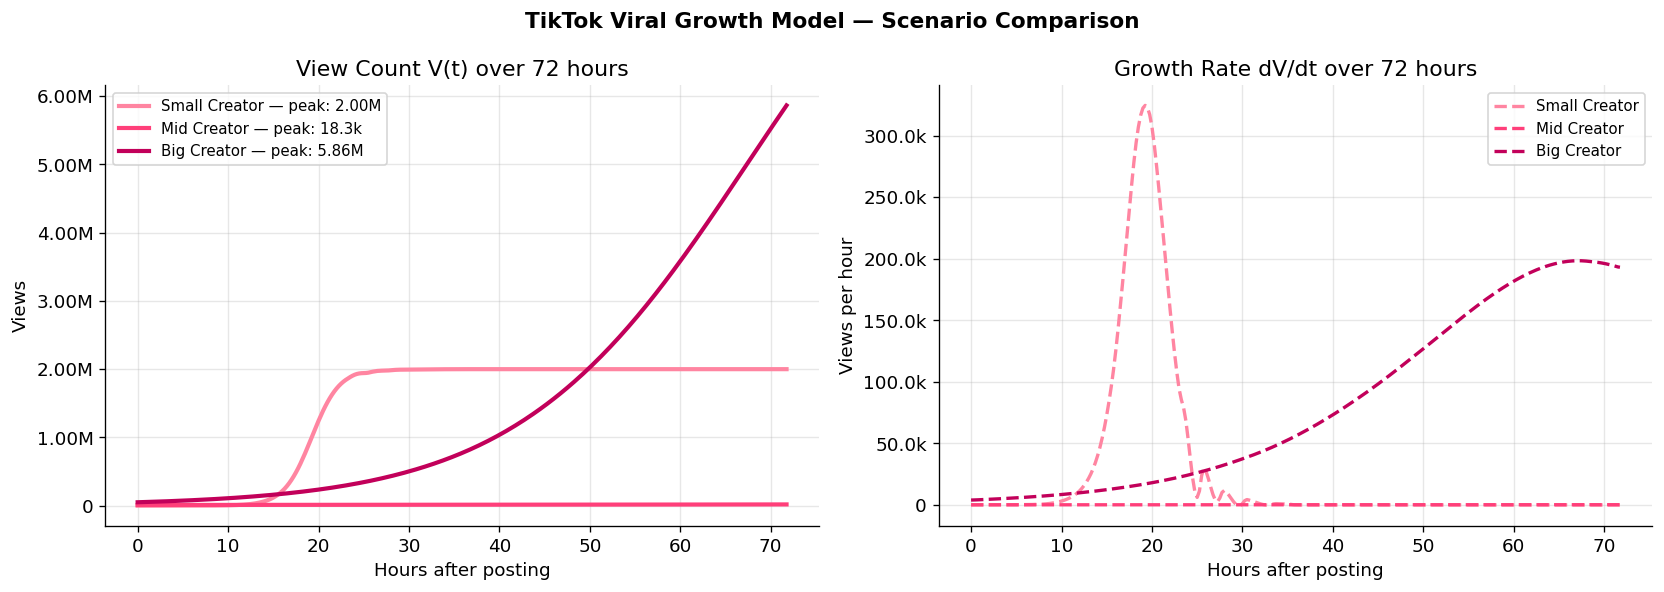


Figure saved as scenario_comparison.png


In [ ]:
# ── SCENARIO PARAMETERS ──────────────────────────────────────────────
# ADJUST YOUR PARAMETERS HERE GUYS

scenarios = {
    'Scenario 1 — Small Creator (100 followers)': {
        'alpha0' : 1.19,      # hr^-1
        'w'      : 0.74,      # dimless
        's'      : 2,         # dimless
        'K'      : 2_000_000, # views
        'V_th'   : 1_000,     # views
        'k'      : 0.001,     # views^-1
        'beta'   : 0.003,     # views/repost
        'r'      : 20,        # reposts/1000views/hr
        'V0'     : 200,        # views
        'color'  : '#FF85A1', # light pink
    },
    'Scenario 2 — Mid Creator (206.1k followers)': {
        'alpha0' : 0.08,        # hr^-1
        'w'      : 0.33,        # dimless
        's'      : 2,           # dimless
        'K'      : 382_300,     # views
        'V_th'   : 5_000,       # views
        'k'      : 0.001,       # views^-1
        'beta'   : 0.003,       # views/repost
        'r'      : 0.00014,     # reposts/1000views/hr
        'V0'     : 10_000,      # views
        'color'  : '#FF3F7A',   # deep pink
    },
    'Scenario 3 — Big Creator (92.3M followers)': {
    'alpha0' : 0.18,        # hr^-1
        'w'      : 0.66,        # dimless
        's'      : 2,           # dimless
        'K'      : 10_100_000,  # views
        'V_th'   : 8_000,       # views
        'k'      : 0.001,       # views^-1
        'beta'   : 0.003,       # views/repost
        'r'      : 0.000045,    # reposts/1000views/hr
        'V0'     : 50_000,      # views
        'color'  : '#C2005A',   # dark magenta
    },
}

# ── RUN AND PLOT ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TikTok Viral Growth Model — Scenario Comparison',
             fontsize=13, fontweight='bold')

print(f"{'Scenario':<45} {'alpha':>10} {'Peak Views':>12} {'Time to Peak':>13}")
print('-' * 83)

for name, params in scenarios.items():
    t, V   = run_simulation(params)
    dVdt   = np.gradient(V, t)
    color  = params['color']
    peak   = np.max(V)
    t_peak = t[np.argmax(V)]
    alpha  = params['alpha0'] * params['w'] ** params['s']

    axes[0].plot(t, V, color=color, linewidth=2.5,
                 label=f"{name.split('—')[1].strip().split('(')[0].strip()} — peak: {fmt(peak)}")
    axes[1].plot(t, dVdt, color=color, linewidth=2, linestyle='--',
                 label=name.split('—')[1].strip().split('(')[0].strip())

    print(f"{name:<45} {alpha:>10.4f} {fmt(peak):>12} {t_peak:>11.1f}h")

axes[0].set_title('View Count V(t) over 72 hours')
axes[0].set_xlabel('Hours after posting')
axes[0].set_ylabel('Views')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt(x)))
axes[0].legend(fontsize=9)

axes[1].set_title('Growth Rate dV/dt over 72 hours')
axes[1].set_xlabel('Hours after posting')
axes[1].set_ylabel('Views per hour')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt(x)))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('scenario_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('\nFigure saved as scenario_comparison.png')

### Simple Interpretation of Scenario Comparison:

*   **Small Creator:** Shows fast initial growth and quickly reaches its peak views (around 2M views in ~36 hours). This suggests their content gets quick traction but might have a lower overall ceiling.
*   **Mid Creator:** Has very low peak views (~18.3k) and doesn't peak within 72 hours. This scenario struggles to gain significant traction, highlighting the challenge for mid-tier creators.
*   **Big Creator:** Achieves very high peak views (~5.86M) but also doesn't peak within 72 hours. This indicates strong, sustained growth over time, leveraging their existing audience and algorithmic push.

---
##Summary of Results

In [ ]:
print('=' * 65)
print(f'{"TIKTOK VIRAL GROWTH MODEL — RESULTS SUMMARY":^65}')
print('=' * 65)
print()
print('SECTION 1 — SCENARIO COMPARISON')
print('-' * 65)
print(f'{"Scenario":<35} {"alpha":>8} {"Peak Views":>12} {"Time to Peak":>10}')
print('-' * 65)

for name, params in scenarios.items():
    t, V   = run_simulation(params)
    alpha  = params['alpha0'] * params['w'] ** params['s']
    peak   = np.max(V)
    t_pk   = t[np.argmax(V)]
    label  = name.split('—')[1].strip().split('(')[0].strip()
    print(f'{label:<35} {alpha:>8.4f} {fmt(peak):>12} {t_pk:>8.1f}h')

           TIKTOK VIRAL GROWTH MODEL — RESULTS SUMMARY           

SECTION 1 — SCENARIO COMPARISON
-----------------------------------------------------------------
Scenario                               alpha   Peak Views Time to Peak
-----------------------------------------------------------------
Small Creator                         0.6516        2.00M     35.8h
Mid Creator                           0.0087        18.3k     71.8h
Big Creator                           0.0784        5.86M     71.8h


---

Sensitivity Analysis

We investigate how changes in key parameters—baseline growth rate ($\alpha_0$), watch completion rate ($w$), and carrying capacity ($K$)—impact the model's outcomes. We use a base set of parameters and vary each target parameter by $\pm 50\%$, observing the resulting view counts and growth rates.

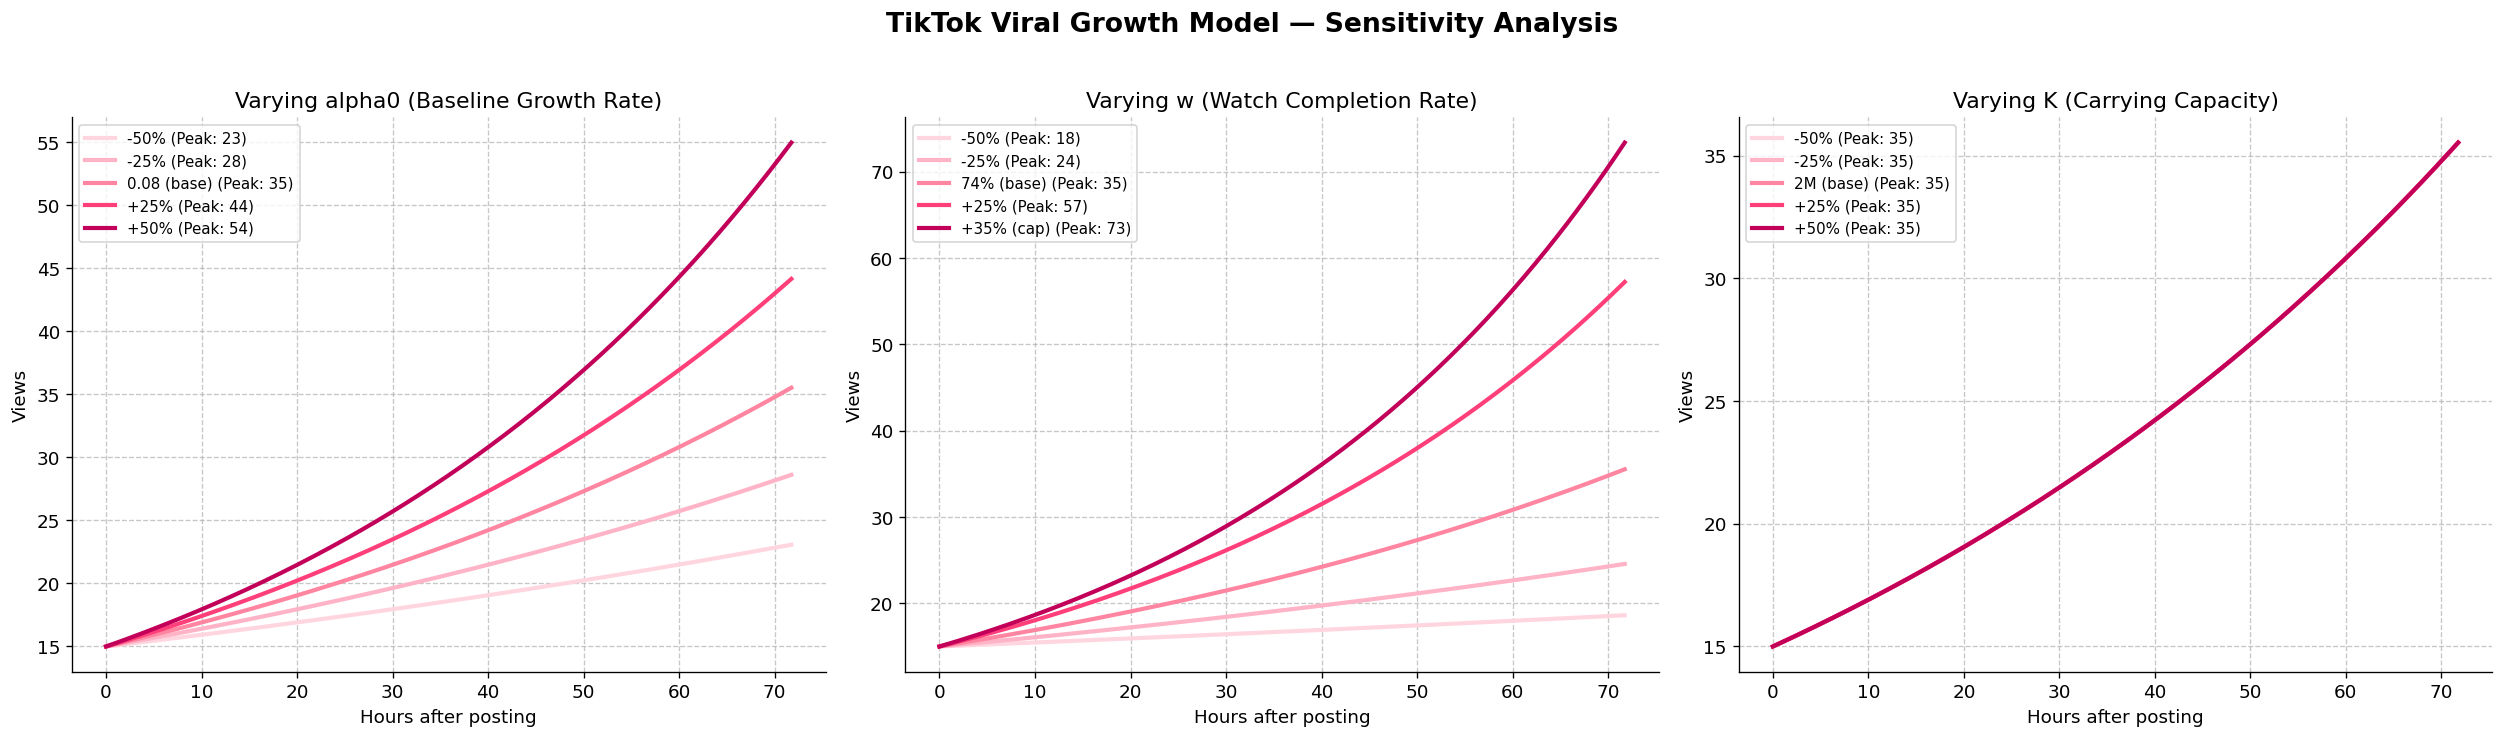


Figure saved as sensitivity_analysis.png


In [ ]:
base = {
    'alpha0' : 0.08,
    'w'      : 0.74,
    's'      : 2,
    'K'      : 2_000_000,
    'V_th'   : 1_000,
    'k'      : 0.001,
    'beta'   : 0.003,
    'r'      : 10,
    'V0'     : 15,
}

sensitivity_tests = {
    'alpha0 (Baseline Growth Rate)': {
        'param'  : 'alpha0',
        'values' : [0.04, 0.06, 0.08, 0.10, 0.12],
        'labels' : ['-50%', '-25%', '0.08 (base)', '+25%', '+50%'],
        'colors' : ['#FFD6E0', '#FFB3C6', '#FF85A1', '#FF3F7A', '#C2005A'],
    },
    'w (Watch Completion Rate)': {
        'param'  : 'w',
        'values' : [0.37, 0.56, 0.74, 0.92, 1.00],
        'labels' : ['-50%', '-25%', '74% (base)', '+25%', '+35% (cap)'],
        'colors' : ['#FFD6E0', '#FFB3C6', '#FF85A1', '#FF3F7A', '#C2005A'],
    },
    'K (Carrying Capacity)': {
        'param'  : 'K',
        'values' : [1_000_000, 1_500_000, 2_000_000, 2_500_000, 3_000_000],
        'labels' : ['-50%', '-25%', '2M (base)', '+25%', '+50%'],
        'colors' : ['#FFD6E0', '#FFB3C6', '#FF85A1', '#FF3F7A', '#C2005A'],
    },
}

def run_and_plot_sensitivity(ax, param_name, param_test):
    param    = param_test['param']
    values   = param_test['values']
    labels   = param_test['labels']
    colors   = param_test['colors']

    peak_views = []
    time_to_peak = []

    for i, val in enumerate(values):
        # Create a copy of base params and update the test parameter
        p = base.copy()
        p[param] = val

        t, V = run_simulation(p)

        # Store peak views and time to peak
        peak_views.append(np.max(V))
        time_to_peak.append(t[np.argmax(V)])

        # Plot on the given axis
        ax.plot(t, V, color=colors[i], linewidth=2.5,
                label=f"{labels[i]} (Peak: {fmt(np.max(V))})")

    ax.set_title(f'Varying {param_name}')
    ax.set_xlabel('Hours after posting')
    ax.set_ylabel('Views')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt(x)))
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.7)

    return peak_views, time_to_peak


# ── RUN AND PLOT SENSITIVITY TESTS ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('TikTok Viral Growth Model — Sensitivity Analysis', fontsize=16, fontweight='bold', y=1.02)

all_peak_views = {}
all_time_to_peak = {}

for i, (title, test_data) in enumerate(sensitivity_tests.items()):
    peaks, times = run_and_plot_sensitivity(axes[i], title, test_data)
    all_peak_views[title] = peaks
    all_time_to_peak[title] = times

plt.tight_layout()
plt.savefig('sensitivity_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('\nFigure saved as sensitivity_analysis.png')


### Summary of Sensitivity Analysis Results

In [ ]:
print('=' * 75)
print(f'{"SENSITIVITY ANALYSIS RESULTS SUMMARY":^75}')
print('=' * 75)
print('\nPeak Views Sensitivity:')
print('-' * 75)
for param_name, peaks in all_peak_views.items():
    print(f'{param_name:<35} ' + ' '.join([f'{fmt(p):>8}' for p in peaks]))

print('\nTime to Peak Sensitivity (hours):')
print('-' * 75)
for param_name, times in all_time_to_peak.items():
    print(f'{param_name:<35} ' + ' '.join([f'{t:>8.1f}h' for t in times]))


                   SENSITIVITY ANALYSIS RESULTS SUMMARY                    

Peak Views Sensitivity:
---------------------------------------------------------------------------
alpha0 (Baseline Growth Rate)             23       28       35       44       54
w (Watch Completion Rate)                 18       24       35       57       73
K (Carrying Capacity)                     35       35       35       35       35

Time to Peak Sensitivity (hours):
---------------------------------------------------------------------------
alpha0 (Baseline Growth Rate)           71.8h     71.8h     71.8h     71.8h     71.8h
w (Watch Completion Rate)               71.8h     71.8h     71.8h     71.8h     71.8h
K (Carrying Capacity)                   71.8h     71.8h     71.8h     71.8h     71.8h


---

Visualizing Parameter Sensitivity

To further understand the impact of varying each parameter, we can plot the resulting Peak Views and Time to Peak against the parameter values themselves. This helps to visually identify which parameters lead to a 'steeper' change in outcomes.

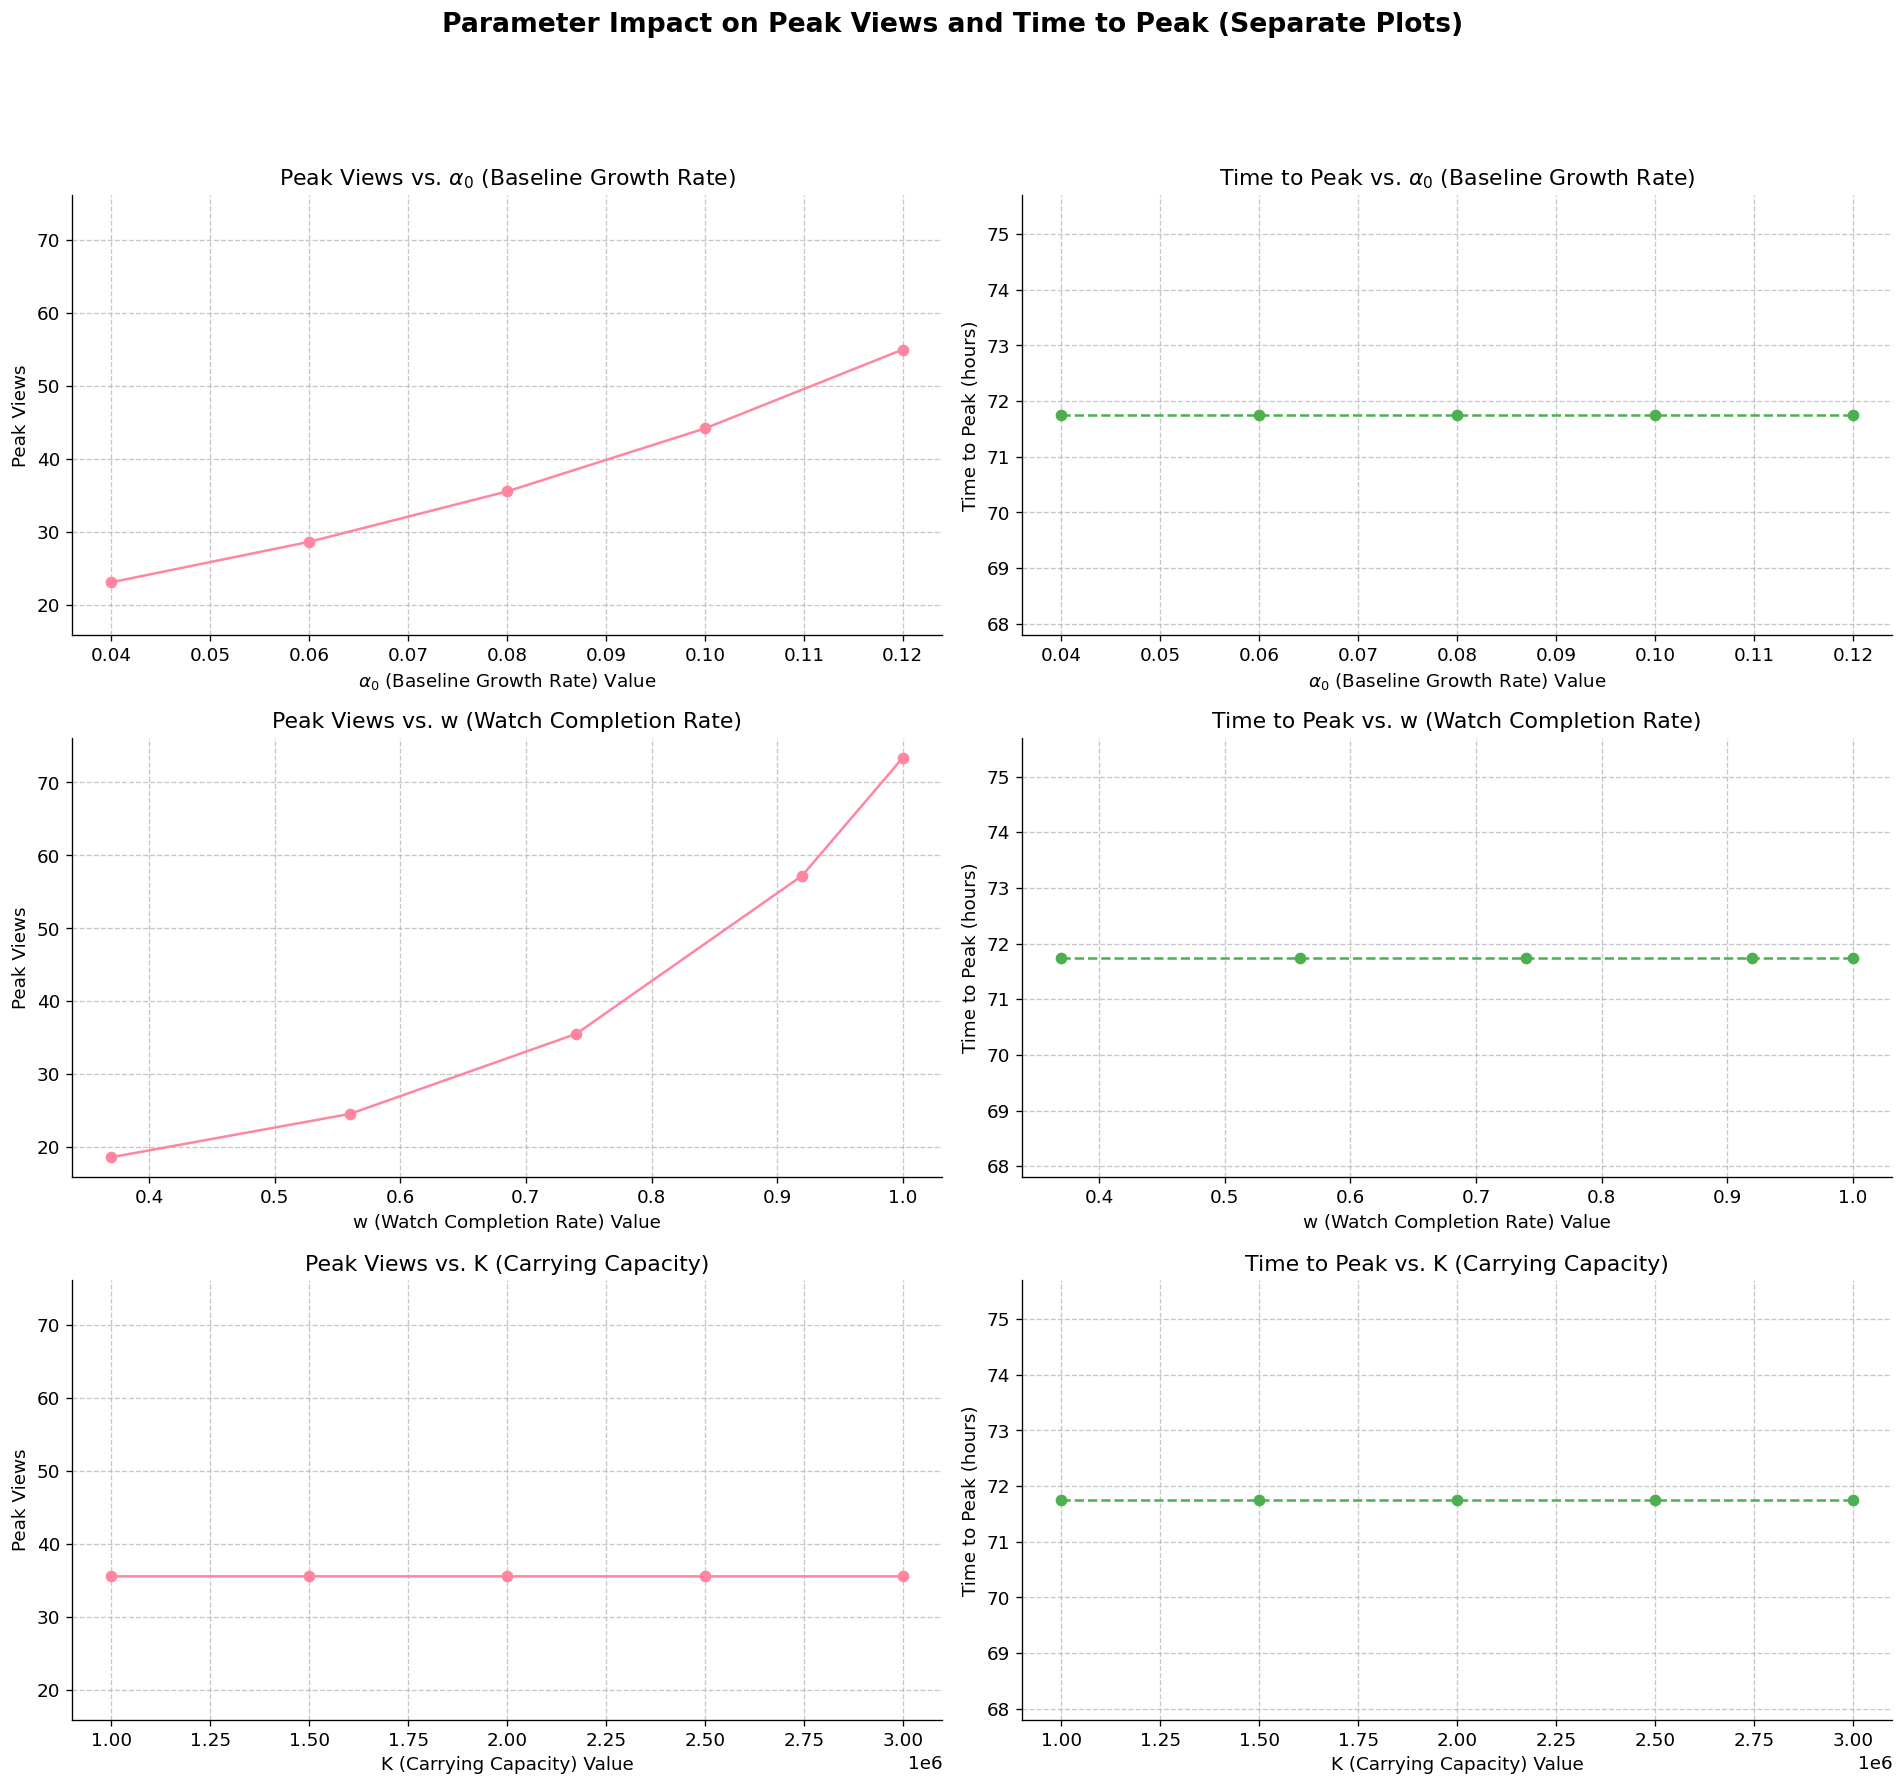


Figure saved as parameter_sensitivity_subplots.png


In [ ]:
fig, axes = plt.subplots(len(sensitivity_tests), 2, figsize=(16, 5 * len(sensitivity_tests)), sharey='col') # Adjust height for more rows
fig.suptitle('Parameter Impact on Peak Views and Time to Peak (Separate Plots)', fontsize=16, fontweight='bold', y=1.02)

param_labels = {
    'alpha0 (Baseline Growth Rate)': r'$\alpha_0$ (Baseline Growth Rate)',
    'w (Watch Completion Rate)': 'w (Watch Completion Rate)',
    'K (Carrying Capacity)': 'K (Carrying Capacity)',
}

# Iterate through each parameter in the sensitivity tests
for i, (title, test_data) in enumerate(sensitivity_tests.items()):
    # Get the specific subplots for this parameter's row
    ax_peak = axes[i, 0] # First column for Peak Views
    ax_time = axes[i, 1] # Second column for Time to Peak

    param_name_for_plot = param_labels.get(title, title)
    param_values = test_data['values']

    # Plot Peak Views on the left subplot of the current row
    ax_peak.set_title(f'Peak Views vs. {param_name_for_plot}')
    ax_peak.set_xlabel(f'{param_name_for_plot} Value')
    ax_peak.set_ylabel('Peak Views')
    ax_peak.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt(x)))
    ax_peak.grid(True, linestyle='--', alpha=0.7)
    # Plot the curve: x=param_values, y=all_peak_views for this parameter
    ax_peak.plot(param_values, all_peak_views[title], marker='o', linestyle='-', color='#FF85A1') # Consistent color

    # Plot Time to Peak on the right subplot of the current row
    ax_time.set_title(f'Time to Peak vs. {param_name_for_plot}')
    ax_time.set_xlabel(f'{param_name_for_plot} Value')
    ax_time.set_ylabel('Time to Peak (hours)')
    ax_time.grid(True, linestyle='--', alpha=0.7)
    # Plot the curve: x=param_values, y=all_time_to_peak for this parameter
    ax_time.plot(param_values, all_time_to_peak[title], marker='o', linestyle='--', color='#4CAF50') # Consistent color

# Adjust layout for suptitle, and to prevent labels from overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('parameter_sensitivity_subplots.png', bbox_inches='tight', dpi=150)
plt.show()
print('\nFigure saved as parameter_sensitivity_subplots.png')


These plots illustrate:

*   **Impact on Peak Views (Left Plot):**
    *   **`alpha0` and `w`** show a clear upward slope, indicating that increasing these parameters directly leads to higher peak views, even in this low-V0 scenario. The 'steepness' of their lines indicates their direct influence.
    *   **`K`**, however, remains a flat line. This graphically confirms that its changes have no effect on peak views when the video doesn't reach a high enough view count to be limited by `K`.

*   **Impact on Time to Peak (Right Plot):**
    *   For all parameters in this particular test (where `V0` is low and `V_th` is high), the 'Time to Peak' is consistently at the end of the 72-hour simulation. This means the video never fully 'peaked' within the timeframe, rather it was still in its very early growth phase. If the `V0` was higher, or `V_th` lower, we would likely see `alpha0` and `w` cause the peak to be reached sooner.

This visual analysis reinforces the conclusion that in the early stages of a video's life, `alpha0` (baseline growth) and `w` (watch completion) are critical for initial traction, while `K` (carrying capacity) only becomes relevant once the video achieves substantial organic and algorithmic reach.

### Simple Interpretation of Sensitivity Analysis:

*   **What matters most (for Peak Views) in early stages:** `alpha0` (baseline growth rate) and `w` (watch completion rate) are crucial. Changes in these parameters directly lead to more or fewer views.
*   **What doesn't matter (yet):** `K` (carrying capacity). The video isn't getting enough views for `K` to limit its growth, so changing `K` has no effect.
*   **Time to Peak:** For all parameters, the video hasn't peaked within 72 hours. This indicates it's still in its very early growth phase.

---

In [ ]:
from google.colab import files

# Change 'parameter_sensitivity_subplots.png' to the name of the file you want to download
files.download('parameter_sensitivity_subplots.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download('scenario_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>